In [ ]:
install.packages("bnlearn")
library(bnlearn)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# VERİ

In [ ]:
if (!requireNamespace("bnlearn", quietly = TRUE)) {
  install.packages("bnlearn")
}
library(bnlearn)

cat("
--- VERİ ---
")

data(coronary)

print(head(coronary))
str(coronary)

cat("
--- VERİ KONTROLÜ ---
")

cat("Gözlem sayısı :", nrow(coronary), "
")
cat("Değişken sayısı:", ncol(coronary), "
")

eksik <- sum(is.na(coronary))
cat("Eksik değer sayısı:", eksik, "
")
if (eksik > 0) {
  cat("UYARI: Eksik değerler bulundu — na.omit() ile temizleniyor
")
  coronary <- na.omit(coronary)
}

hepsi_faktor <- all(sapply(coronary, is.factor))
cat("Tüm değişkenler faktör mü?", hepsi_faktor, "
")
if (!hepsi_faktor) {
  cat("UYARI: Faktör olmayanlar dönüştürülüyor
")
  coronary[] <- lapply(coronary, as.factor)
}

cat("
Değişken düzeyleri:
")
for (col in colnames(coronary)) {
  cat(sprintf("  %-12s: %s
", col, paste(levels(coronary[[col]]), collapse=" / ")))
}

learning.test <- coronary

cat("
Veri kontrolü tamamlandı. Devam ediliyor...
")


--- VERİ ---
  Smoking M. Work P. Work Pressure Proteins Family
1      no      no      no     <140       <3    neg
2      no      no      no     <140       <3    neg
3      no      no      no     <140       <3    neg
4      no      no      no     <140       <3    neg
5      no      no      no     <140       <3    neg
6      no      no      no     <140       <3    neg
'data.frame':	1841 obs. of  6 variables:
 $ Smoking : Factor w/ 2 levels "no","yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ M. Work : Factor w/ 2 levels "no","yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ P. Work : Factor w/ 2 levels "no","yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ Pressure: Factor w/ 2 levels "<140",">140": 1 1 1 1 1 1 1 1 1 1 ...
 $ Proteins: Factor w/ 2 levels "<3",">3": 1 1 1 1 1 1 1 1 1 1 ...
 $ Family  : Factor w/ 2 levels "neg","pos": 1 1 1 1 1 1 1 1 1 1 ...

--- VERİ KONTROLÜ ---
Gözlem sayısı : 1841 
Değişken sayısı: 6 
Eksik değer sayısı: 0 
Tüm değişkenler faktör mü? TRUE 

Değişken düzeyleri:
  Smoking     : no / yes
  M. Work 

# MODEL


--- MODEL ---

Whitelist (Zorunlu Kenarlar):
     from       to
1 Smoking Pressure
2  Family Pressure

Blacklist (Yasaklı Kenarlar):
      from      to
1 Pressure Smoking
2 Proteins Smoking
3 Pressure  Family

  Bayesian network learned via Hybrid methods

  model:
   [Smoking][Family][P. Work|Smoking][Pressure|Smoking:Family]
   [M. Work|Smoking:P. Work:Pressure][Proteins|Smoking:M. Work]
  nodes:                                 6 
  arcs:                                  8 
    undirected arcs:                     0 
    directed arcs:                       8 
  average markov blanket size:           3.33 
  average neighbourhood size:            2.67 
  average branching factor:              1.33 

  learning algorithm:                    Max-Min Hill-Climbing 
  constraint-based method:               Max-Min Parent Children 
  conditional independence test:         Mutual Information (disc.) 
  score-based method:                    Hill-Climbing 
  score:                         

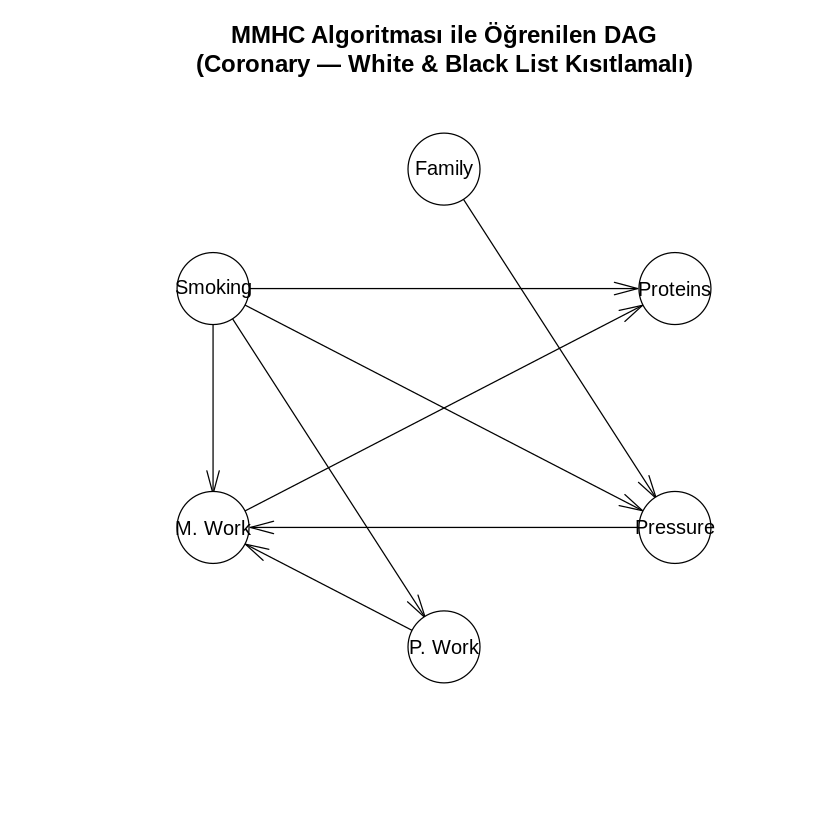

In [ ]:
cat("
--- MODEL ---
")

wl <- data.frame(
  from = c("Smoking", "Family"),
  to   = c("Pressure", "Pressure")
)

bl <- data.frame(
  from = c("Pressure", "Proteins", "Pressure"),
  to   = c("Smoking",  "Smoking",  "Family")
)

cat("
Whitelist (Zorunlu Kenarlar):
")
print(wl)
cat("
Blacklist (Yasaklı Kenarlar):
")
print(bl)

dag_model <- mmhc(learning.test, whitelist = wl, blacklist = bl)

print(dag_model)

cat("
Öğrenilen Modelin Kenarları (Arcs):
")
print(arcs(dag_model))

plot(dag_model, main = "MMHC Algoritması ile Öğrenilen DAG
(Coronary — White & Black List Kısıtlamalı)")

# DEĞERLENDİRME


--- DEĞERLENDİRME ---

Bootstrap Sonuçları (İlk 6 satır):
     from       to strength direction
1 Smoking  M. Work    1.000 0.6610000
2 Smoking  P. Work    0.970 0.5206186
3 Smoking Pressure    1.000 1.0000000
4 Smoking Proteins    0.946 1.0000000
5 Smoking   Family    0.034 0.4117647
6 M. Work  Smoking    1.000 0.3390000

Oldukça Güvenilir Kenarlar (Strength > 0.85):
      from       to strength direction
1  Smoking  M. Work    1.000 0.6610000
2  Smoking  P. Work    0.970 0.5206186
3  Smoking Pressure    1.000 1.0000000
4  Smoking Proteins    0.946 1.0000000
9  M. Work Proteins    1.000 0.5620000
12 P. Work  M. Work    1.000 0.6400000
29  Family Pressure    1.000 1.0000000

Sınırdaki Kenarlar (Strength 0.50 - 0.85):
       from       to strength direction
8   M. Work Pressure    0.568 0.5246479
10  M. Work   Family    0.512 0.4707031
17 Pressure  M. Work    0.568 0.4753521
19 Pressure Proteins    0.526 0.8631179
24 Proteins Pressure    0.526 0.1368821
27   Family  M. Work    0.512 0.

agg_record_2cb412b6f90 
                     2

dag_gorsel.png kaydedildi

Pipeline tamamlandı.


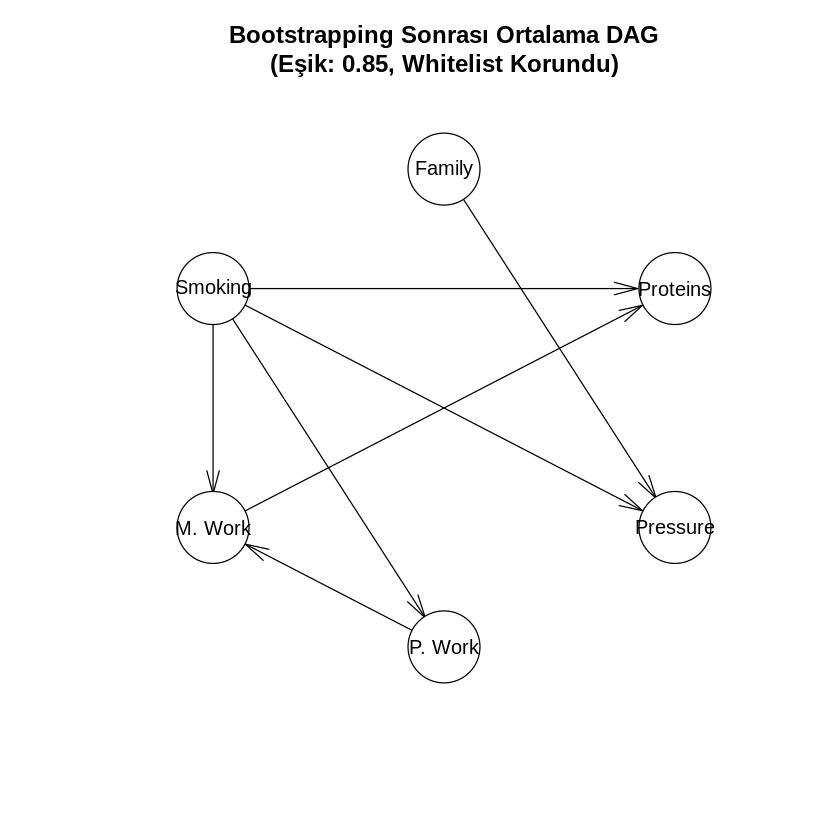

In [ ]:
cat("\n--- DEĞERLENDİRME ---\n")

set.seed(42)
boot_sonuclari <- boot.strength(
  data = learning.test,
  R = 500,
  algorithm = "mmhc",
  algorithm.args = list(whitelist = wl, blacklist = bl)
)

cat("\nBootstrap Sonuçları (İlk 6 satır):\n")
print(head(boot_sonuclari))

guvenilir_kenarlar <- boot_sonuclari[boot_sonuclari$strength > 0.85 & boot_sonuclari$direction > 0.50, ]
cat("\nOldukça Güvenilir Kenarlar (Strength > 0.85):\n")
print(guvenilir_kenarlar)

sinirda_kenarlar <- boot_sonuclari[boot_sonuclari$strength > 0.50 & boot_sonuclari$strength <= 0.85, ]
cat("\nSınırdaki Kenarlar (Strength 0.50 - 0.85):\n")
print(sinirda_kenarlar)

cat("\n--- WHITELIST TUTARLILIK KONTROLÜ ---\n")
for (i in 1:nrow(wl)) {
  from_node <- wl$from[i]
  to_node   <- wl$to[i]
  satir <- boot_sonuclari[
    boot_sonuclari$from == from_node & boot_sonuclari$to == to_node,
  ]
  if (nrow(satir) > 0) {
    str_val <- satir$strength
    cat(sprintf("Whitelist kenarı %s -> %s: bootstrap strength = %.3f\n",
                from_node, to_node, str_val))
    if (str_val < 0.85) {
      cat(sprintf("  UYARI: Bu kenar whitelist'te zorunlu ama bootstrap eşiğinin (0.85) altında (%.3f)\n",
                  str_val))
      cat("  Bu kenar ortalama DAG'a zorla ekleniyor — domain knowledge kararı\n")
    } else {
      cat("  OK: Kenar bootstrap ile de tutarlı\n")
    }
  }
}

ort_dag <- averaged.network(boot_sonuclari, threshold = 0.85)

for (i in 1:nrow(wl)) {
  kenar_var <- any(
    arcs(ort_dag)[,1] == wl$from[i] & arcs(ort_dag)[,2] == wl$to[i]
  )
  if (!kenar_var) {
    ort_dag <- set.arc(ort_dag, wl$from[i], wl$to[i])
    cat(sprintf("Whitelist kenarı %s -> %s ortalama DAG'a eklendi\n", wl$from[i], wl$to[i]))
  }
}

cat("\nOrtalama DAG Kenarları (Threshold = 0.85, whitelist korundu):\n")
print(arcs(ort_dag))

plot(ort_dag, main = "Bootstrapping Sonrası Ortalama DAG\n(Eşik: 0.85, Whitelist Korundu)")

cat("\n--- ÇIKTI KAYDETME ---\n")

bic_skoru <- score(ort_dag, data = learning.test, type = "bic")
cat(sprintf("BIC Skoru: %.4f\n", bic_skoru))

write.csv(data.frame(bic = bic_skoru), "bic_skoru.csv", row.names = FALSE)
cat("bic_skoru.csv kaydedildi\n")

saveRDS(ort_dag, "ortalama_dag.rds")
cat("ortalama_dag.rds kaydedildi\n")

write.csv(boot_sonuclari, "bootstrap_sonuclari.csv", row.names = FALSE)
cat("bootstrap_sonuclari.csv kaydedildi\n")

write.csv(arcs(ort_dag), "dag_kenarlari.csv", row.names = FALSE)
cat("dag_kenarlari.csv kaydedildi\n")

png("dag_gorsel.png", width = 800, height = 600)
plot(ort_dag, main = "Ortalama DAG (Bootstrap Eşik: 0.85)")
dev.off()
cat("dag_gorsel.png kaydedildi\n")

cat("\nPipeline tamamlandı.\n")